# Multi-Class Logistic Regression from Scratch using NumPy

## Project Description
This project implements a Multi-Class Logistic Regression model completely from scratch using only **NumPy** for vectorized computations. The model is designed to classify sign language images by performing forward passes, computing cross-entropy loss, and optimizing parameters using gradient descent.

## Dataset
The model is trained and evaluated using the Sign Language MNIST dataset located in the `data/` directory:
* `data/sign-mnist_train.csv` - Training set
* `data/sign-mnist_test.csv` - Test set

Each row in the dataset represents a flattened grayscale image, where:
* The **first column** contains the target label (the corresponding sign/letter class).
* The **remaining columns** contain the pixel intensity values used as features for the model.

## Features
- **Framework-Free Implementation:** Optimization and training loops are written from scratch without deep learning libraries.
- **Vectorized Operations:** Efficient matrix operations using NumPy for fast gradient computation and updates.
- **Type Annotations:** Fully documented code with explicit Python type hints for clarity and robustness.
- **Evaluation:** Includes loss/accuracy tracking and a visual confusion matrix to evaluate classification performance.

In [1]:
# !uv add seaborn
# !uv add tableprint
!pip install prettytable

In [2]:
!pip install tableprint

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Union
import seaborn as sns
from PIL import Image
import tableprint as tab

plt.rc('font', **{'size' : 18})

# Procesarea datelor de intrare

In [8]:
path_train = './data/sign_mnist_train.csv'
path_test = './data/sign_mnist_test.csv'


train_data = pd.read_csv(path_train)
test_data=pd.read_csv(path_test)

assert(train_data.shape) == (27455, 785),f'The file was not read correctly: a content of the form was read {train_data.shape}'
assert(test_data.shape) == (7172, 785),f'The file was not read correctly: a content of the form was read {test_data.shape}'


train_data.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Number of classes: 24


/tmp/ipykernel_3375/4127651476.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=train_data, palette=palette)


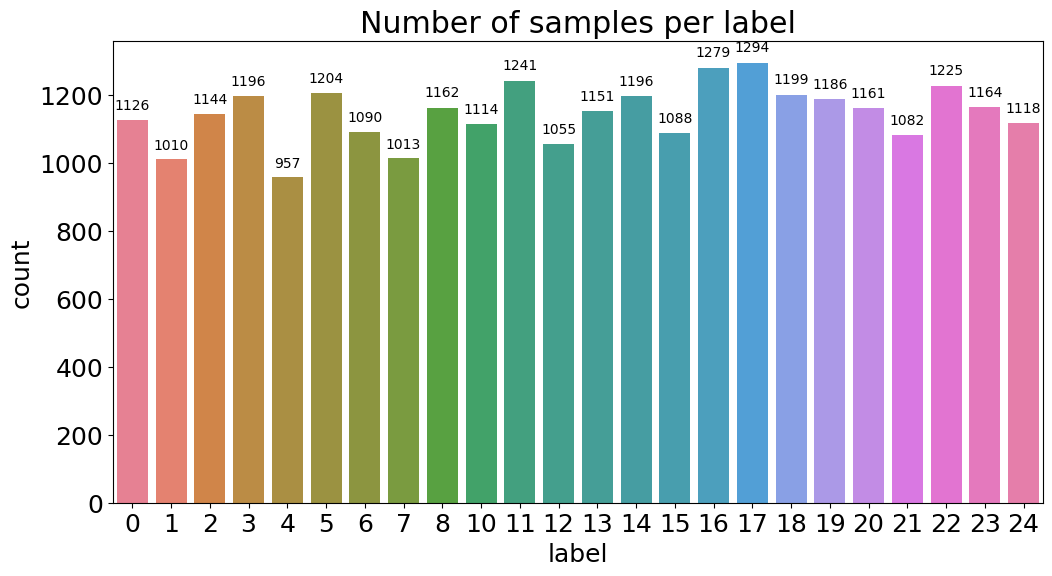

In [9]:
num_classes = train_data['label'].nunique()
print(f'Number of classes: {num_classes}')
palette = sns.color_palette('husl', num_classes)

plt.figure(figsize=(12,6))

palette = sns.color_palette('husl', num_classes)

ax = sns.countplot(x='label', data=train_data, palette=palette)
plt.title('Number of samples per label')

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.02*height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.show()

In [10]:

train_x: np.ndarray=train_data.iloc[:, 1:].values
train_y: np.ndarray=train_data.iloc[:, 0].values
test_x: np.ndarray=test_data.iloc[:, 1:].values
test_y: np.ndarray=test_data.iloc[:, 0].values


assert train_x.shape == (27455, 784)
assert train_y.shape == (27455,)
assert test_x.shape == (7172, 784)
assert test_y.shape == (7172,)

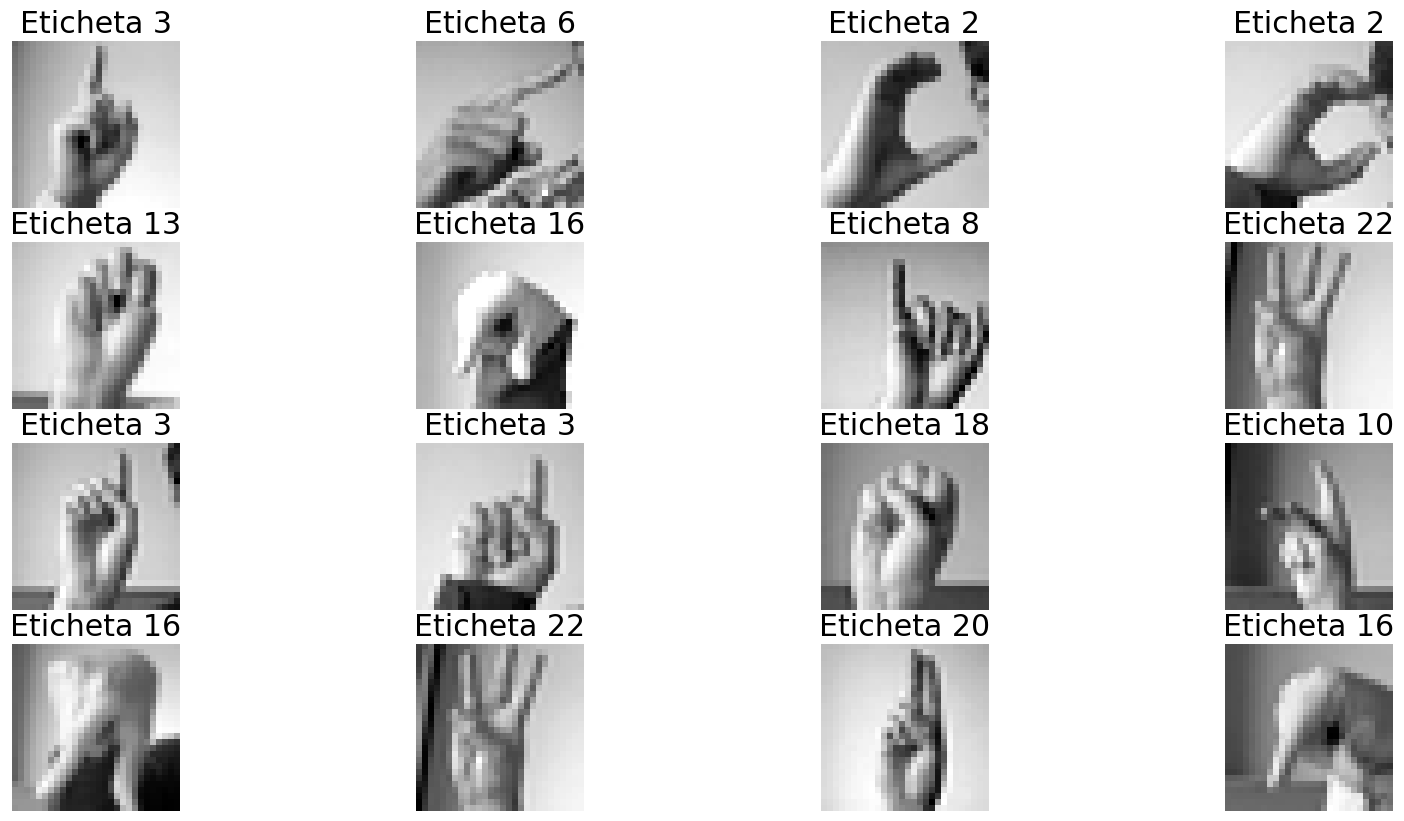

In [11]:
def show_samples(x_set, y_set):
    size = x_set.shape[0]

    fig, ax = plt.subplots(size // 4, 4, figsize=(20, 10))
    for k in range(size):
        row, col = k // 4, k % 4

        pixels = np.array(x_set[k], dtype='uint8')

        n = int(np.sqrt(len(pixels)))
        assert n**2 == len(pixels)
        pixels = pixels.reshape(n, n)
        ax[row, col].imshow(pixels, cmap='gray')
        ax[row, col].set_title('Eticheta {label}'.format(label=y_set[k]))
        ax[row, col].axis('off')

    plt.show()

show_samples(train_x[:16, :], train_y[:16])

Să decodificăm etichetele imaginilor:


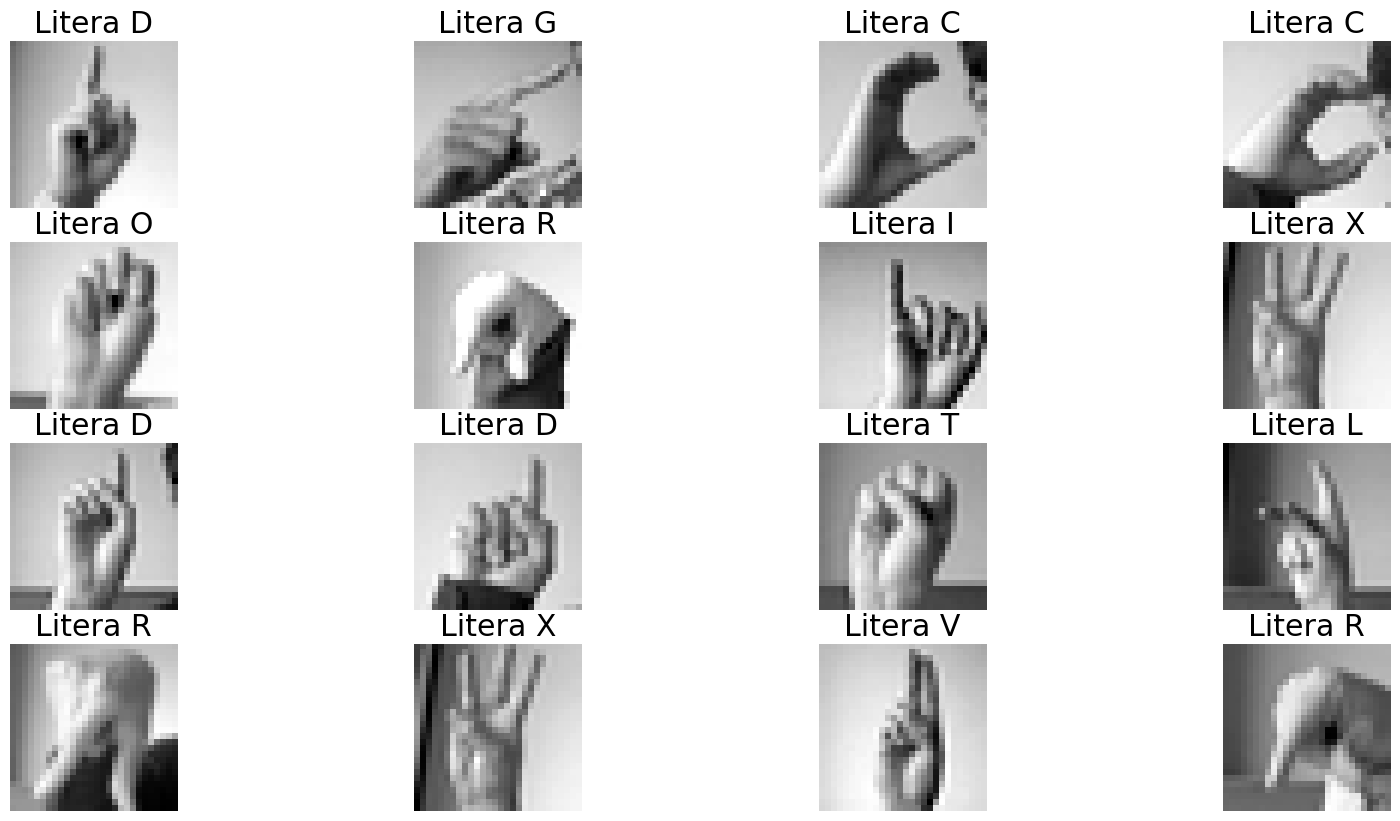

In [12]:
labels_map = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',10:'K',
             11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',
             20:'U',21:'V',22:'W',23:'X',24:'Y'}

classes = list(labels_map.values())

def show_samples(x_set, y_set):
    size = x_set.shape[0]

    fig, ax = plt.subplots(size // 4, 4, figsize=(20, 10))
    for k in range(size):
        row, col = k // 4, k % 4

        pixels = np.array(x_set[k], dtype='uint8')

        n = int(np.sqrt(len(pixels)))
        assert n**2 == len(pixels)
        pixels = pixels.reshape(n, n)
        ax[row, col].imshow(pixels, cmap='gray')
        ax[row, col].set_title('Litera {label}'.format(label=classes[y_set[k]]))
        ax[row, col].axis('off')

    plt.show()

show_samples(train_x[:16, :], train_y[:16])


In [13]:
print("Class   Image number \n ", pd.Series(train_y).value_counts())
print("Class 9 is missing! \n Hand movements are required to identify the letter J and Z, not just still images.\nWe renumber the labels:")
 # Relabel the top_classes_train to 0-9
print(len(classes))
print("Labels map for top classes:")
new_labels = {cls: i for i, cls in enumerate(list(labels_map.keys()))}
print(new_labels)
train_y = np.array([new_labels[label.item()] for label in train_y])
print("Relabeled train labels shape:", train_y.shape)
# Relabel the top_classes_test to 0-9
test_y = np.array([new_labels[label] for label in test_y])
print("Relabeled test labels shape:", test_y.shape)

Class   Image number 
  17    1294
16    1279
11    1241
22    1225
5     1204
18    1199
14    1196
3     1196
19    1186
23    1164
8     1162
20    1161
13    1151
2     1144
0     1126
24    1118
10    1114
6     1090
15    1088
21    1082
12    1055
7     1013
1     1010
4      957
Name: count, dtype: int64
Class 9 is missing! 
 Hand movements are required to identify the letter J and Z, not just still images.
We renumber the labels:
24
Labels map for top classes:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23}
Relabeled train labels shape: (27455,)
Relabeled test labels shape: (7172,)


In [14]:
def augment_matrix(x: np.ndarray) -> np.ndarray:

    column_ones:np.ndarray=np.ones((x.shape[0],1))
    result:np.ndarray = np.hstack((column_ones,x))
    return result

train_x_bin_ext:np.ndarray = augment_matrix(train_x)
test_x_bin_ext:np.ndarray = augment_matrix(test_x)

assert train_x_bin_ext.shape == (27455, 785)
assert test_x_bin_ext.shape == (7172, 785)
assert np.all(train_x_bin_ext[:, 0] == 1)
assert np.all(test_x_bin_ext[:, 0] == 1)


In [15]:

def normalize(x: np.ndarray) -> np.ndarray:
    return x/255

train_x_ext:np.ndarray = augment_matrix(normalize(train_x))
test_x_ext:np.ndarray = augment_matrix(normalize(test_x))

assert train_x_ext.shape == (27455, 785)
assert test_x_ext.shape == (7172, 785)
assert np.all(train_x_ext[:, 0] == 1)
assert np.all(test_x_ext[:, 0] == 1)


assert np.all(train_x_ext <= 1)
assert np.all(test_x_ext <= 1)
assert np.all(train_x_ext >= 0)
assert np.all(test_x_ext >= 0)

In [16]:

k = num_classes

print("Number of selected classes:", k)


train_x_all_ext:np.ndarray = augment_matrix(normalize(train_x))
test_x_all_ext:np.ndarray = augment_matrix(normalize(test_x))

assert train_x_ext.shape == (27455, 785)
assert test_x_ext.shape == (7172, 785)
assert np.all(train_x_all_ext[:, 0] == 1)
assert np.all(test_x_all_ext[:, 0] == 1)
assert np.all(train_x_all_ext <= 1)
assert np.all(test_x_all_ext <= 1)
assert np.all(train_x_all_ext >= 0)
assert np.all(test_x_all_ext >= 0)

Number of selected classes: 24


In [17]:

def one_hot(val: int, classes: int) -> np.ndarray:

    assert 0 <= val < classes,f'The valuea {val} it is not between 0 and {classes}'

    result:np.ndarray = np.zeros(classes, dtype=int)
    result[val]:int=1
    result:np.ndarray=result.reshape(1, classes)

    assert result.shape == (1, classes)
    return result

assert np.all(one_hot(7, k) == np.array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]))
assert np.all(one_hot(3, k) == np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]))
train_y_all = np.concatenate([one_hot(int(i), k) for i in train_y])
test_y_all = np.concatenate([one_hot(int(i), k) for i in test_y])
assert train_y_all.shape == (27455, 24),f'Forma train_y_all: {train_y_all.shape}'
assert test_y_all.shape == (7172, 24),f'forma test_y_all: {test_y_all.shape}'
assert np.all((train_y_all != 0) == (train_y_all == 1))

In [18]:

m, n = train_x_all_ext.shape
np.random.seed(11)
theta = np.random.randn(n, k)
assert (train_x_all_ext @ theta).shape == (m, k)

In [19]:

def softmax(x: np.ndarray, theta: np.ndarray) -> np.ndarray:
    assert x.shape[1] == theta.shape[0]
    k:int =theta.shape[1]
    x_theta:np.ndarray=x@theta
    e_x_theta:np.ndarray =np.exp(x_theta)
    e_x_theta_1:np.ndarray = np.sum(e_x_theta,axis=1,keepdims=True)
    return e_x_theta / e_x_theta_1

m, n = train_x_all_ext.shape
np.random.seed(11)
theta = np.random.randn(n, k)
smax = softmax(train_x_all_ext, theta)
assert smax.shape == (m, k)
assert np.all((smax.sum(axis=1) - 1) < 1e-12)

In [20]:

def cost(x, y, theta, lmbda):
    m:int = x.shape[0]
    one_m:np.ndarray =np.ones((m,1))
    one_k:np.ndarray =np.ones((theta.shape[1],1))
    y_hat:np.ndarray = softmax(x,theta)
    term1:float=-1/m*np.sum(y*np.log(y_hat))
    thet:np.ndarray=theta[1:,:]
    term2:float = (lmbda/2) *np.sum(thet**2)
    return (term1 + term2).flatten()

m, n = train_x_all_ext.shape
np.random.seed(11)
theta = np.random.randn(n, k)
assert (cost(train_x_all_ext, train_y_all, theta=theta, lmbda=0.2) - 1985.31901041) < 1e-6, f'The cost calculated is {cost(train_x_all_ext, train_y_all, theta=theta, lmbda=0.2)}'

In [21]:

def deltas(x, y, theta, lmbda):
    m:int= x.shape[0]
    y_hat:np.ndarray = softmax(x,theta)
    theta_0:np.ndarray = theta.copy()
    theta_0[0, :] = 0
    er:np.ndarray=y-y_hat
    g1:np.ndarray=-(1/m)*(x.T@er)
    g2:np.ndarray=lmbda*theta_0
    g:np.ndarray=g1+g2
    return g

m, n = train_x_all_ext.shape
np.random.seed(11)
theta = np.random.randn(n, k)
grad = deltas(train_x_all_ext, train_y_all, theta=theta, lmbda=0.2)

assert grad.shape == (n, k)

In [22]:
def calculate_accurracy(set_x, set_y, theta):
    y_hat:np.ndarray = softmax(set_x,theta)
    max_y_hat:np.ndarray =np.argmax(y_hat,axis=1)
    max_y_all:np.ndarray =np.argmax(set_y,axis=1)
    return (max_y_hat == max_y_all).sum() / set_x.shape[0] * 100.0

In [23]:

k = num_classes

lmbda, alpha = 0.05 , 0.1
m, n = train_x_all_ext.shape
np.random.seed(11)
theta = np.random.randn(n, k)

epochs = 500
values = []
accurracies = []
for i in range(epochs):
    theta -= alpha * deltas(train_x_all_ext, train_y_all, theta, lmbda)
    if (i % 10 == 0):
        values.append(cost(train_x_all_ext, train_y_all, theta, lmbda))
        accurracies.append(calculate_accurracy(test_x_all_ext, test_y_all, theta))
        print("epoch: ", i, "cost: ", values[-1], "accuracy: ", accurracies[-1])
        lmbda *= 0.9

print("last costs: %g" % values[-1])

epoch:  0 cost:  [488.45042805] accuracy:  4.894032348020079
epoch:  10 cost:  [389.18323288] accuracy:  4.503625209146681
epoch:  20 cost:  [323.27995509] accuracy:  4.155047406581149
epoch:  30 cost:  [271.02007915] accuracy:  4.280535415504741
epoch:  40 cost:  [228.93421296] accuracy:  4.392080312325711
epoch:  50 cost:  [194.71420139] accuracy:  4.601226993865031
epoch:  60 cost:  [166.64256301] accuracy:  5.0055772448410485
epoch:  70 cost:  [143.4262299] accuracy:  5.716675962074735
epoch:  80 cost:  [124.08089292] accuracy:  6.162855549358617
epoch:  90 cost:  [107.84950017] accuracy:  6.664807585052984
epoch:  100 cost:  [94.14411117] accuracy:  6.999442275515895
epoch:  110 cost:  [82.50392433] accuracy:  7.571109871723368
epoch:  120 cost:  [72.56464523] accuracy:  7.891801450083659
epoch:  130 cost:  [64.03590344] accuracy:  8.616843279419967
epoch:  140 cost:  [56.68444477] accuracy:  9.146681539319577
epoch:  150 cost:  [50.3215092] accuracy:  9.774121583937536
epoch:  16

/tmp/ipykernel_3375/3079264215.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("last costs: %g" % values[-1])


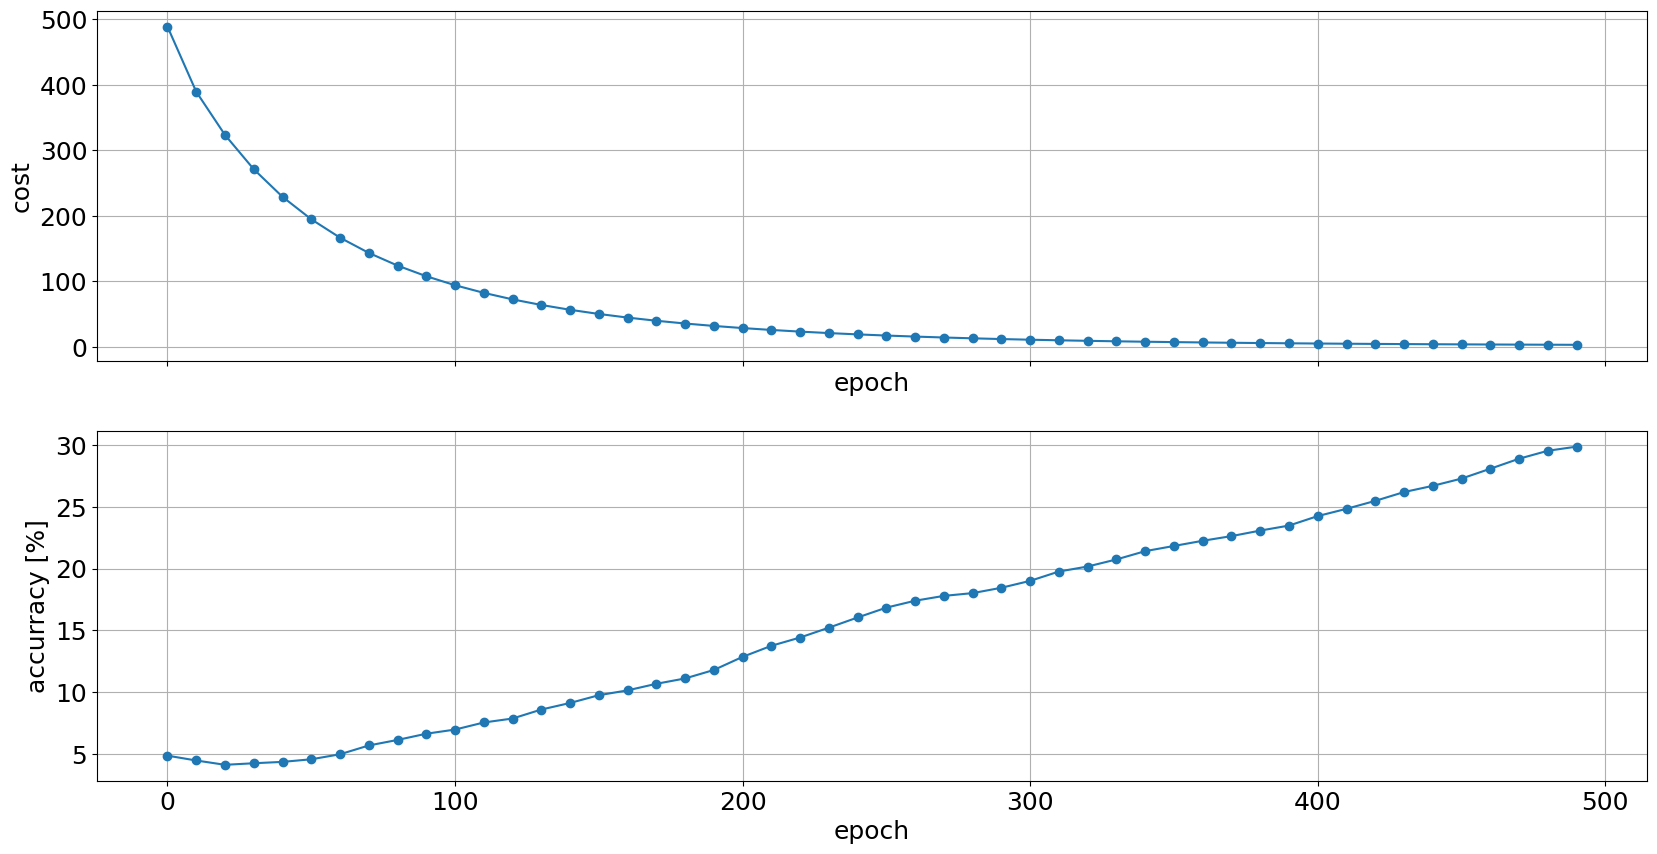

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
ax[0].plot([x * 10 for x in range(len(values))], values, 'o-')
ax[0].set_xlabel('epoch') ; ax[0].set_ylabel('cost')
ax[0].grid()
ax[1].plot([x * 10 for x in range(len(accurracies))], accurracies, 'o-')
ax[1].set_xlabel('epoch') ; ax[1].set_ylabel('accurracy [%]')
ax[1].grid()
plt.show()

In [25]:

pred = np.argmax(softmax(test_x_all_ext,theta),axis=1)
actual =np.argmax(test_y_all,axis=1)
equalities = np.sum(pred == actual)
print("Test accuracy: %2.2f%%" % ( equalities/test_y_all.shape[0]*100 ))



Test accuracy: 30.20%


In [26]:
from prettytable import PrettyTable

pred = (softmax(test_x_all_ext, theta) >= 0.5) * 1
actual = test_y_all
k_2 = int(k/2)

conf_matrix = np.zeros((k, k))
for i in range(k):
    for j in range(k):
        conf_matrix[i,j] = np.sum(np.logical_and(actual[:,i]==1, pred[:,j]==1))

def print_split_confusion_matrix(conf_matrix, k, k_2):

    # First half
    print("╔" + "═"*50 + "╗")
    print("║        FIRST HALF - CLASSES 0 to {:<2}         ║".format(k_2-1))
    print("╚" + "═"*50 + "╝")

    pt1 = PrettyTable()
    pt1.field_names = ['Act\nPred'] + [f'P{x}' for x in range(k)] + ['Total']
    for i in range(k_2):
        row = [f'A{i}'] + [int(conf_matrix[i,j]) for j in range(k)] + [int(np.sum(conf_matrix[i,:]))]
        pt1.add_row(row)
    pt1.add_row(['Total'] + [int(np.sum(conf_matrix[:k_2, j])) for j in range(k)] + [int(np.sum(conf_matrix[:k_2, :]))])
    print(pt1)

    # Second half
    print("\n╔" + "═"*50 + "╗")
    print("║        SECOND HALF - CLASSES {:<2} to {:<2}         ║".format(k_2, k-1))
    print("╚" + "═"*50 + "╝")

    pt2 = PrettyTable()
    pt2.field_names = ['Act\nPred'] + [f'P{x}' for x in range(k)] + ['Total']
    for i in range(k_2, k):
        row = [f'A{i}'] + [int(conf_matrix[i,j]) for j in range(k)] + [int(np.sum(conf_matrix[i,:]))]
        pt2.add_row(row)
    pt2.add_row(['Total'] + [int(np.sum(conf_matrix[k_2:, j])) for j in range(k)] + [int(np.sum(conf_matrix[k_2:, :]))])
    print(pt2)

print_split_confusion_matrix(conf_matrix, k, k_2)

╔══════════════════════════════════════════════════╗
║        FIRST HALF - CLASSES 0 to 11         ║
╚══════════════════════════════════════════════════╝
+-------+----+-----+-----+----+----+----+----+-----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-------+
|    Act
Pred    | P0 |  P1 |  P2 | P3 | P4 | P5 | P6 |  P7 | P8 | P9 | P10 | P11 | P12 | P13 | P14 | P15 | P16 | P17 | P18 | P19 | P20 | P21 | P22 | P23 | Total |
+-------+----+-----+-----+----+----+----+----+-----+----+----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-----+-------+
|   A0  | 60 |  0  |  0  | 0  | 0  | 0  | 0  |  0  | 0  | 0  |  0  |  14 |  29 |  0  |  0  |  0  |  0  |  40 |  0  |  0  |  0  |  0  |  0  |  0  |  143  |
|   A1  | 0  |  34 |  0  | 0  | 0  | 0  | 0  |  0  | 0  | 24 |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  0  |  33 |  0  |  0  |  3  |  0  |   94  |
|   A2  | 0  |  0  | 160 | 0  | 0  | 0  | 0  |  16 | 0  | 0  |

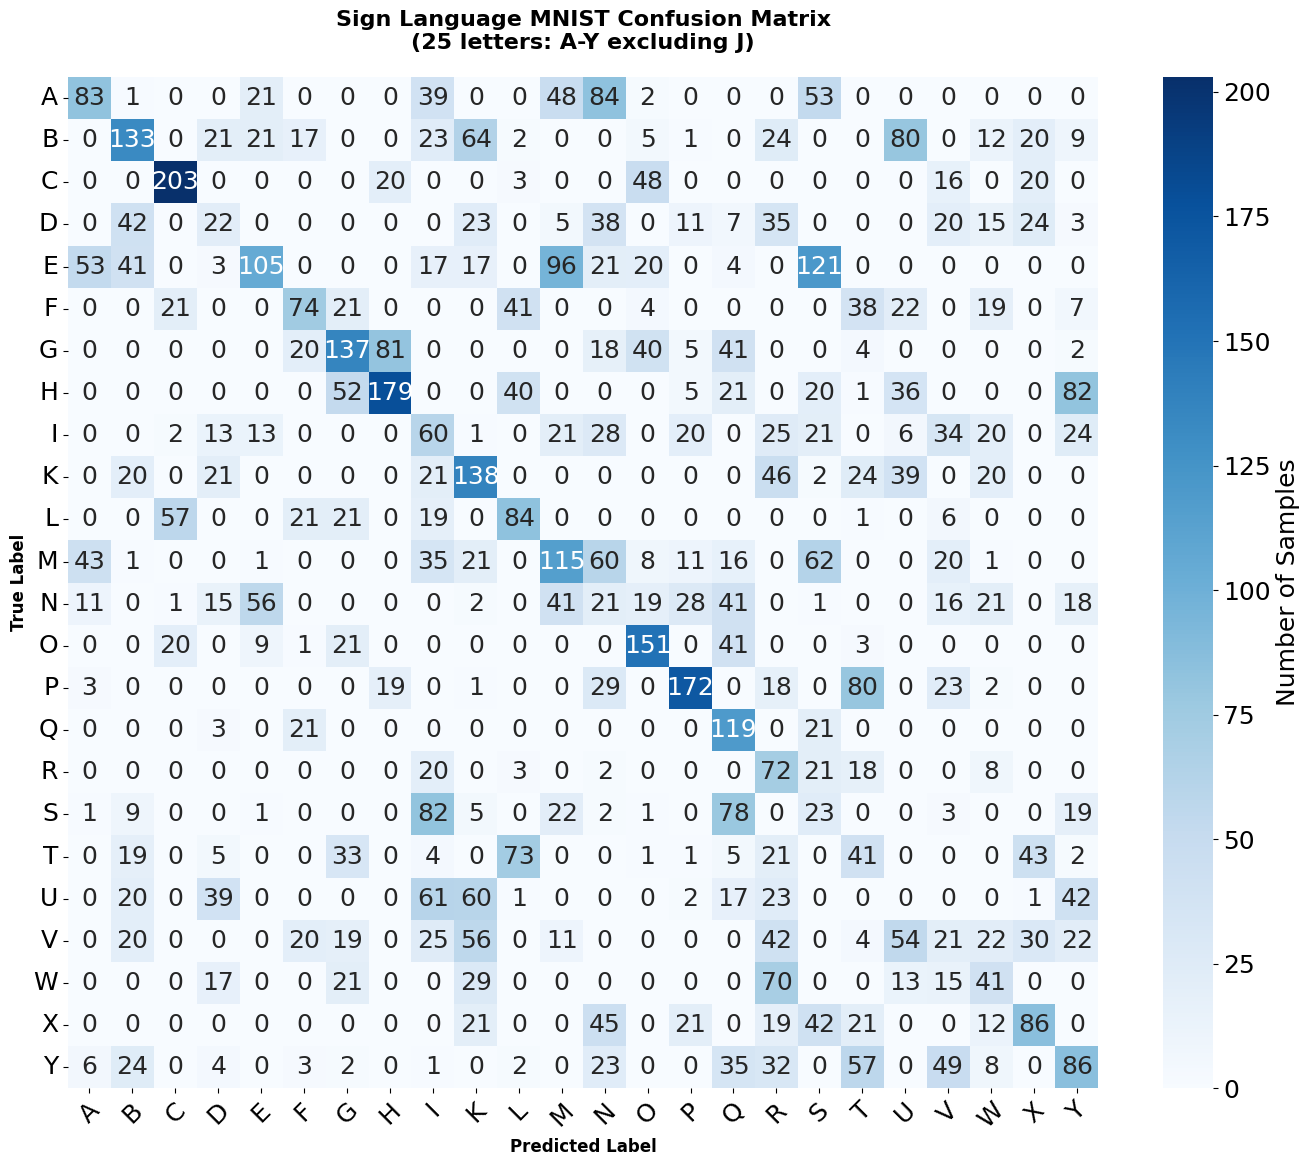

In [27]:
from sklearn.metrics import confusion_matrix
pred = np.argmax(softmax(test_x_all_ext, theta), axis=1)
actual = np.argmax(test_y_all, axis=1)
asl_letters = list(labels_map.values())
cm = confusion_matrix(actual, pred)

plt.figure(figsize=(14, 12))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=asl_letters,
            yticklabels=asl_letters,
            cbar_kws={'label': 'Number of Samples'})

plt.title('Sign Language MNIST Confusion Matrix\n(25 letters: A-Y excluding J)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()